# FDSI benchmark: cross-config ablation comparison (triangular conditions)

Compares every already-tuned config variant found under `data/fdsi_results/` along the axes explored
across the `fdsi_06`-`fdsi_11` notebooks:

- **update rule**: error-driven natural-gradient control (default) vs. `lr_alone` (blind, un-braked
  natural-gradient ascent) vs. `max_rel_delta` (the older fixed-relative-clip scheme, predating the
  `lr_v`/`lr_b` natural-gradient normalization -- this is the "how large a relative update is allowed
  per batch" axis)
- **whitening target**: `kl_to_identity` vs `kl_to_cal`
- **separation-vector iterations**: `max_iter_b` (1 vs 5 fixed-point steps per batch)
- **V-to-B coupling**: `wh_b_coupling` on/off

This notebook does **no new decomposition or optimisation** -- it only loads the per-unit RoA
(`snr*dB_roa_labels.npz`), the shared calibration SIL scores (`apply_best_config/.../snr*dB_cbss_cal.npz`),
and the tuned hyperparameters (`optimisation/best_config_*.json`) that the other `fdsi_0X` notebooks
already computed and cached to disk. Scope is the four **triangular** ramp conditions
(5s/10s/20s/40s) -- `staircase` is excluded to keep the comparison to a single, continuously-varying
contraction profile.

Because several of these result directories are produced by notebooks that may still be running
concurrently, the config-discovery step below is written to **skip any config with no cached RoA
results yet** rather than error -- re-running this notebook later will pick up newly finished configs
automatically.

In [ ]:
import json, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.gaussian_process')
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

ROOT = Path('..', '..', 'data', 'muniverse_simulations')
CAL_ROOT = ROOT / 'apply_best_config'
TRIANGULAR = ['triangular-ramp5s', 'triangular-ramp10s', 'triangular-ramp20s', 'triangular-ramp40s']
COND_ORDER = TRIANGULAR
SNRS = [15, 20, 25, 30]

## 1. Discover every tuned config for the triangular conditions

Reads every `best_config_triangular-ramp*.json` under `data/fdsi_results/*/optimisation/`. Each file
already stores the *full* set of flags used for that run (`lr_alone`, `wh_mode`, `wh_b_coupling`,
`max_iter_b`, ...) plus the tuned step size -- either `lr_v`/`lr_b` (natural-gradient scheme) or
`max_rel_delta_v`/`max_rel_delta_b` (older fixed-clip scheme). Both are folded into a scheme-tagged
`step_v`/`step_b` pair so they can be compared side by side.

In [2]:
cfg_rows = []
for cfgfile in glob.glob(str(ROOT / '*' / 'optimisation' / 'best_config_triangular-ramp*.json')):
    p = Path(cfgfile)
    variant = p.parent.parent.name
    cond = p.stem.replace('best_config_', '')
    cfg = json.load(open(p))
    if 'wh_learning_rate' in cfg:
        scheme, sv, sb = 'natural_gradient', cfg['wh_learning_rate'], cfg['sv_learning_rate']
    elif 'max_rel_delta_v' in cfg:
        scheme, sv, sb = 'max_rel_delta', cfg['max_rel_delta_v'], cfg['max_rel_delta_b']
    else:
        continue
    cfg_rows.append(dict(
        variant=variant, condition=cond, update_scheme=scheme,
        lr_alone=bool(cfg.get('lr_alone', False)),
        wh_mode=cfg.get('wh_mode'),
        coupling=bool(cfg.get('wh_b_coupling', False)),
        sv_epochs=cfg.get('sv_epochs'),
        silence_penalty=bool(cfg.get('silence_penalty', False)),
        optim_loss=cfg.get('optim_loss', 'single_obj'),
        step_v=sv, step_b=sb,
    ))
cfg_df = pd.DataFrame(cfg_rows)


def scheme_tag(r):
    if r.update_scheme == 'max_rel_delta':
        return 'maxRelDelta'
    return 'lrAlone' if r.lr_alone else 'errCtrl'


def wh_tag(m):
    return 'ident' if m == 'kl_to_identity' else 'cal'


def make_label(r):
    multi = 'multi' if r.optim_loss == 'multi_obj' else 'single'
    coup = 'T' if r.coupling else 'F'
    pen = 'T' if r.silence_penalty else 'F'
    return (scheme_tag(r) + '|' + wh_tag(r.wh_mode) + '|it' + str(r.sv_epochs)
            + '|c' + coup + '|sp' + pen + '|' + multi)


cfg_df['label'] = cfg_df.apply(make_label, axis=1)

# a handful of configs are genuine re-runs of the identical axes under a different
# directory name -- disambiguate those labels with the variant name so nothing collides
label_check = cfg_df.drop_duplicates('variant')[['variant', 'label']]
dupe_labels = set(label_check[label_check.duplicated('label', keep=False)]['label'])
if dupe_labels:
    cfg_df['label'] = cfg_df.apply(
        lambda r: r['label'] + ' [' + r['variant'] + ']' if r['label'] in dupe_labels else r['label'],
        axis=1,
    )

print(f"discovered {cfg_df.variant.nunique()} config variants x {cfg_df.condition.nunique()} conditions")
cfg_df.drop_duplicates('variant')[['variant', 'label', 'update_scheme', 'lr_alone', 'wh_mode',
                                    'coupling', 'sv_epochs', 'silence_penalty']].reset_index(drop=True)

discovered 16 config variants x 4 conditions


,variant,label,update_scheme,lr_alone,wh_mode,coupling,max_iter_b,silence_penalty
0,lr_alone_kl_to_cal_penalty,lrAlone|cal|it5|cF|spT|single,natural_gradient,True,kl_to_cal,False,5,True
1,lr_alone_kl_to_cal_penalty_multiobj,lrAlone|cal|it5|cF|spT|multi,natural_gradient,True,kl_to_cal,False,5,True
2,lr_alone_kl_to_identity_penalty_coupling,lrAlone|ident|it5|cT|spT|single [lr_alone_kl_t...,natural_gradient,True,kl_to_identity,True,5,True
3,lr_alone_kl_to_identity_penalty_singleobj,lrAlone|ident|it1|cF|spT|single,natural_gradient,True,kl_to_identity,False,1,True
4,lr_alone_kl_to_identity_penalty_singleobj_coup...,lrAlone|ident|it1|cT|spT|single,natural_gradient,True,kl_to_identity,True,1,True
5,lr_alone_kl_to_identity_penalty_sv5_coupling_s...,lrAlone|ident|it5|cT|spT|single [lr_alone_kl_t...,natural_gradient,True,kl_to_identity,True,5,True
6,lr_alone_kl_to_identity_penalty_sv5_singleobj,lrAlone|ident|it5|cF|spT|single,natural_gradient,True,kl_to_identity,False,5,True
7,lr_kl_to_cal_penalty,errCtrl|cal|it5|cF|spT|single,natural_gradient,False,kl_to_cal,False,5,True
8,lr_kl_to_identity_penalty,errCtrl|ident|it5|cF|spT|single,natural_gradient,False,kl_to_identity,False,5,True
9,lr_kl_to_identity_penalty_coupling,errCtrl|ident|it5|cT|spT|single,natural_gradient,False,kl_to_identity,True,5,True


### Label abbreviations

Each config is labeled `<scheme>|<wh_mode>|it<N>|c<T/F>|sp<T/F>|<obj>`:

- **scheme** -- the update rule:
  - `errCtrl` -- default error-driven, EMA-normalized natural-gradient control (`lr_alone=False`): step
    size is proportional to the signed, calibration-referenced error, so it self-scales down to ~0 once
    the model matches calibration and self-scales up when it drifts.
  - `lrAlone` -- blind, un-braked natural-gradient ascent (`lr_alone=True`): no error term, no
    calibration reference -- a fixed-rate step applied every batch regardless of how right or wrong the
    model currently is.
  - `maxRelDelta` -- the older fixed-relative-clip scheme that predates the `lr_v`/`lr_b`
    natural-gradient normalization: the step is a fixed fraction of the current V/B norm each batch.
- **wh_mode** -- whitening target: `ident` = `kl_to_identity`, `cal` = `kl_to_cal`.
- **it\<N\>** -- `max_iter_b`: number of separation-vector fixed-point iterations per batch (1 or 5).
- **c\<T/F\>** -- `wh_b_coupling`: whether the whitening (V) update's frame correction is also propagated
  to the separation matrix (B).
- **sp\<T/F\>** -- `silence_penalty`: whether inactive units get a fixed penalty instead of being
  excluded (NaN) from the loss.
- **single/multi** -- `optim_loss`: whether CMA-ES optimized `wh_loss + sv_loss` as one scalar
  (`single_obj`) or as a 3-objective Pareto front (`multi_obj`).
- A trailing `[variant_name]` appears only when two result directories happen to share identical config
  flags (a genuine re-run under a different directory name) -- it exists purely to keep the label
  unique, it is not an extra axis of comparison.

## 2. Load per-unit adapted/fixed RoA and calibration SIL

`sil` (silhouette score) is a **calibration-time** property of each unit -- it does not depend on the
adaptation config -- so it is loaded once from the shared `apply_best_config` cache and joined onto
every config variant by `(subject, condition, snr, unit)`. It's included as a reference/sanity column,
not a performance metric: it should look essentially constant across configs, which is itself a useful
check that units are being matched correctly.

In [3]:
unit_rows = []
all_variant_dirs = [d.name for d in ROOT.iterdir() if d.is_dir() and d.name != 'apply_best_config']
for variant in all_variant_dirs:
    vdir = ROOT / variant
    sub_dirs = sorted(d.name for d in vdir.iterdir() if d.is_dir() and d.name.startswith('sub-'))
    for sub in sub_dirs:
        for cond in TRIANGULAR:
            rdir = vdir / sub / cond
            if not rdir.exists():
                continue
            for snr in SNRS:
                roa_f = rdir / f'snr{snr}dB_roa_labels.npz'
                if not roa_f.exists():
                    continue
                d = np.load(roa_f)
                roa_fixed, roa_adapted = d['roa_fixed'], d['roa_adapted']
                cal_f = CAL_ROOT / sub / cond / f'snr{snr}dB_cbss_cal.npz'
                sil = np.load(cal_f)['sil'] if cal_f.exists() else None
                for i in range(len(roa_fixed)):
                    unit_rows.append(dict(
                        variant=variant, condition=cond, subject=sub, snr=snr, unit=i,
                        roa_fixed=float(roa_fixed[i]), roa_adapted=float(roa_adapted[i]),
                        sil=float(sil[i]) if sil is not None and i < len(sil) else np.nan,
                    ))
unit_df = pd.DataFrame(unit_rows)

df = unit_df.merge(cfg_df, on=['variant', 'condition'], how='inner')
print(f"per-unit rows: {len(df)}  |  variants with cached RoA: {df.variant.nunique()} / {cfg_df.variant.nunique()}")

per-unit rows: 9090  |  variants with cached RoA: 15 / 16


## 3. Summary metrics per config x condition

Mean/median adapted RoA, the fraction of units clearing 90% RoA, and mean SIL -- averaged across all
subjects and SNR levels for a first overview (per-SNR spread is visible in the boxplots below).
Configs discovered in step 1 but with no cached RoA yet (still-running notebooks) are reported and
excluded rather than silently plotted as blank.

In [4]:
def summarize(g):
    return pd.Series({
        'mean_roa_adapted':   g.roa_adapted.mean() * 100,
        'median_roa_adapted': g.roa_adapted.median() * 100,
        'pct_roa90':          (g.roa_adapted >= 0.90).mean() * 100,
        'mean_sil':           g.sil.mean(),
        'mean_roa_fixed':     g.roa_fixed.mean() * 100,
        'n_units':            len(g),
    })


summary = df.groupby(['variant', 'label', 'condition']).apply(summarize, include_groups=False).reset_index()

label_order_full = (cfg_df.sort_values(['update_scheme', 'lr_alone', 'wh_mode', 'coupling', 'sv_epochs'],
                                        ascending=[True, False, True, True, True])
                          .drop_duplicates('label')['label'].tolist())
labels_with_data = set(summary['label'])
missing_labels = [l for l in label_order_full if l not in labels_with_data]
label_order = [l for l in label_order_full if l in labels_with_data]
if missing_labels:
    print("excluded (no cached RoA results yet -- likely still running):")
    for l in missing_labels:
        print("  -", l)

summary.pivot(index='label', columns='condition', values='mean_roa_adapted').reindex(label_order)[COND_ORDER].round(1)

excluded (no cached RoA results yet -- likely still running):
  - lrAlone|ident|it5|cT|spT|single [lr_alone_kl_to_identity_penalty_sv5_coupling_singleobj]


condition,triangular-ramp5s,triangular-ramp10s,triangular-ramp20s,triangular-ramp40s
label,,,,
maxRelDelta|cal|it5|cF|spF|single,64.1,66.1,71.9,76.2
maxRelDelta|cal|it5|cF|spT|single,64.8,64.6,72.6,76.1
maxRelDelta|ident|it5|cF|spF|single,67.7,68.3,79.0,79.3
maxRelDelta|ident|it5|cF|spT|single,66.7,68.7,77.4,79.6
lrAlone|cal|it5|cF|spT|single,58.1,54.2,58.7,75.2
lrAlone|cal|it5|cF|spT|multi,54.0,51.6,59.0,75.2
lrAlone|ident|it1|cF|spT|single,22.8,48.9,75.3,86.1
lrAlone|ident|it5|cF|spT|single,1.3,59.0,0.7,82.3
lrAlone|ident|it1|cT|spT|single,29.7,58.6,37.8,85.3


## 4. Heatmaps -- config x ramp duration, first overview

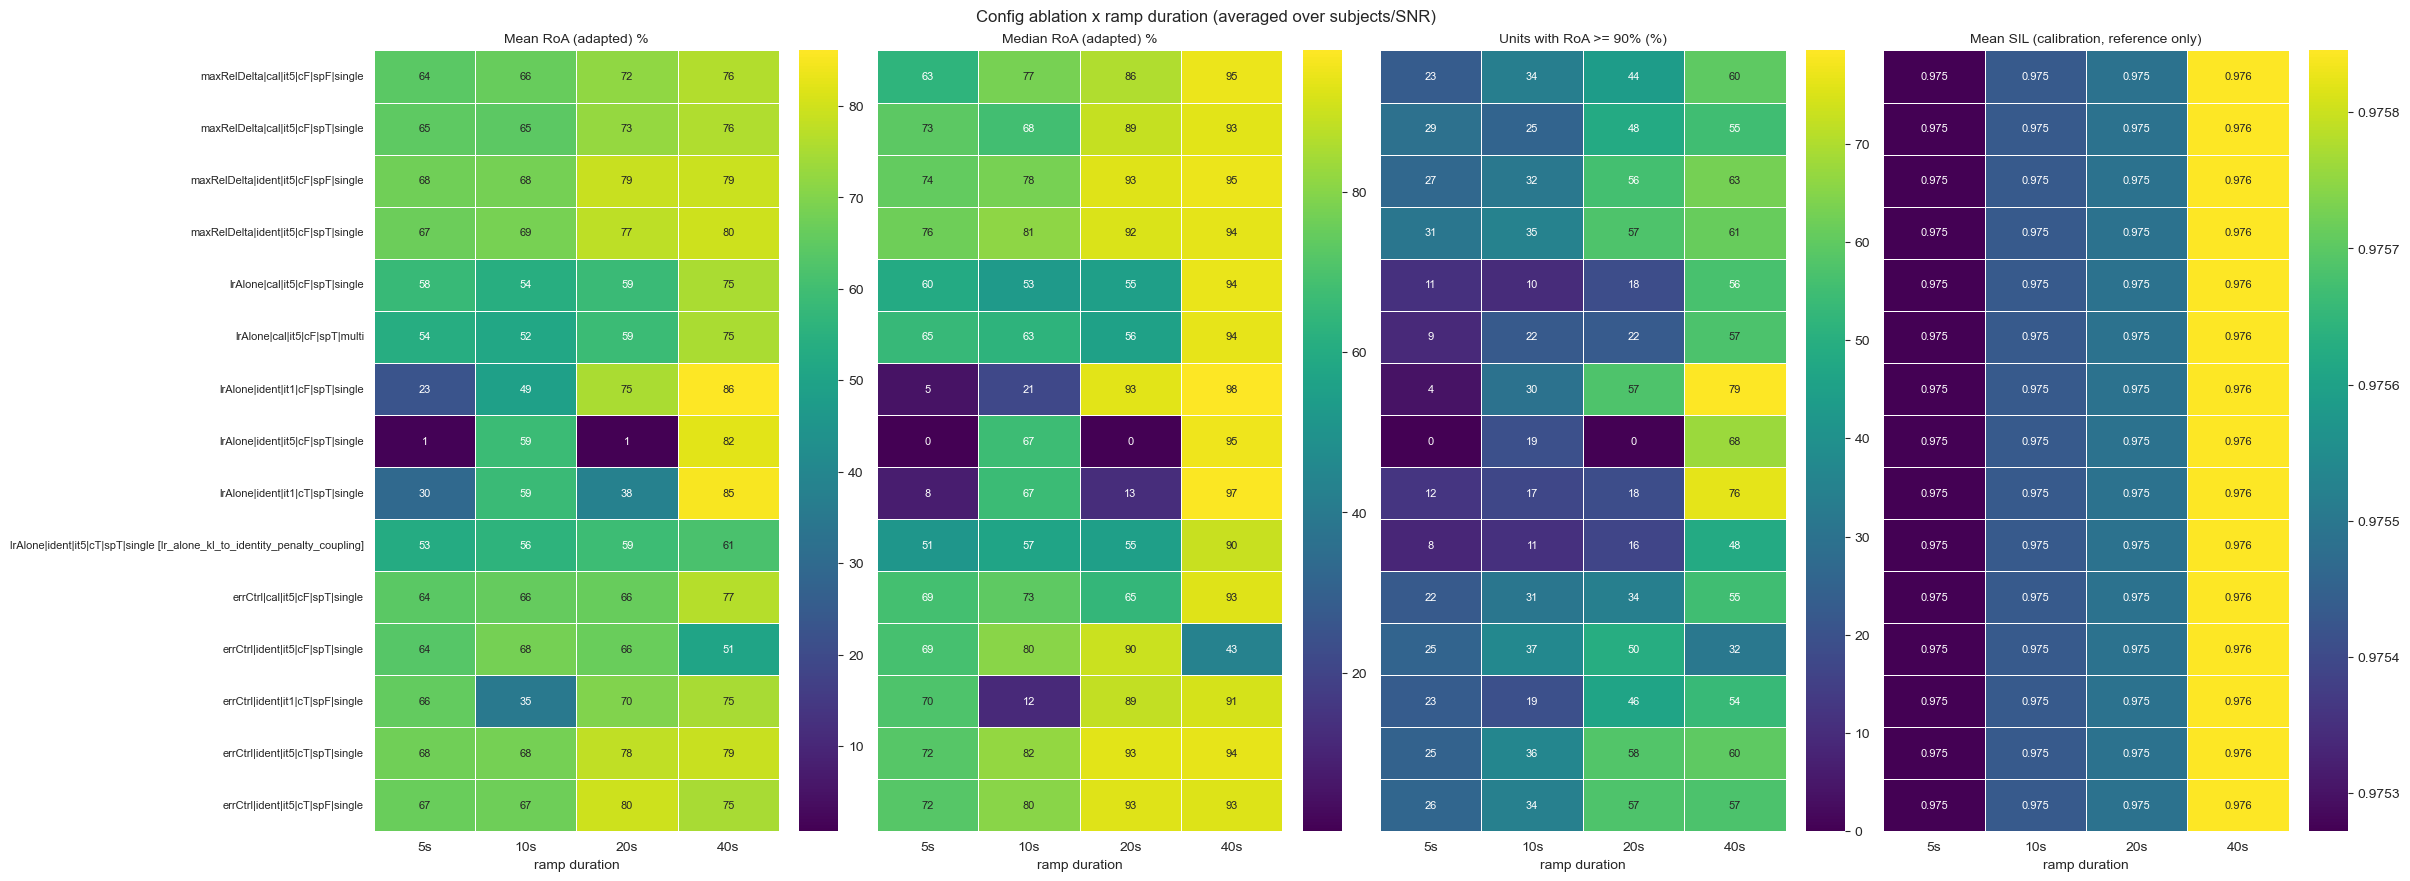

In [5]:
metrics = [('mean_roa_adapted', 'Mean RoA (adapted) %', '.0f'),
           ('median_roa_adapted', 'Median RoA (adapted) %', '.0f'),
           ('pct_roa90', 'Units with RoA >= 90% (%)', '.0f'),
           ('mean_sil', 'Mean SIL (calibration, reference only)', '.3f')]

n_rows = len(label_order)
fig, axes = plt.subplots(1, 4, figsize=(24, 0.38 * n_rows + 3), constrained_layout=True)
for j, (ax, (col, title, fmt)) in enumerate(zip(axes, metrics)):
    piv = summary.pivot(index='label', columns='condition', values=col).reindex(label_order)[COND_ORDER]
    piv.columns = [c.replace('triangular-ramp', '') for c in piv.columns]
    sns.heatmap(piv, ax=ax, cmap='viridis', annot=True, fmt=fmt, cbar=True,
                linewidths=0.5, linecolor='white', annot_kws={'fontsize': 8})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('ramp duration')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)
    if j > 0:
        ax.set_yticklabels([])
        ax.tick_params(left=False)
fig.suptitle('Config ablation x ramp duration (averaged over subjects/SNR)', fontsize=12)
plt.show()

## 5. Boxplots -- per-unit adapted-RoA distribution

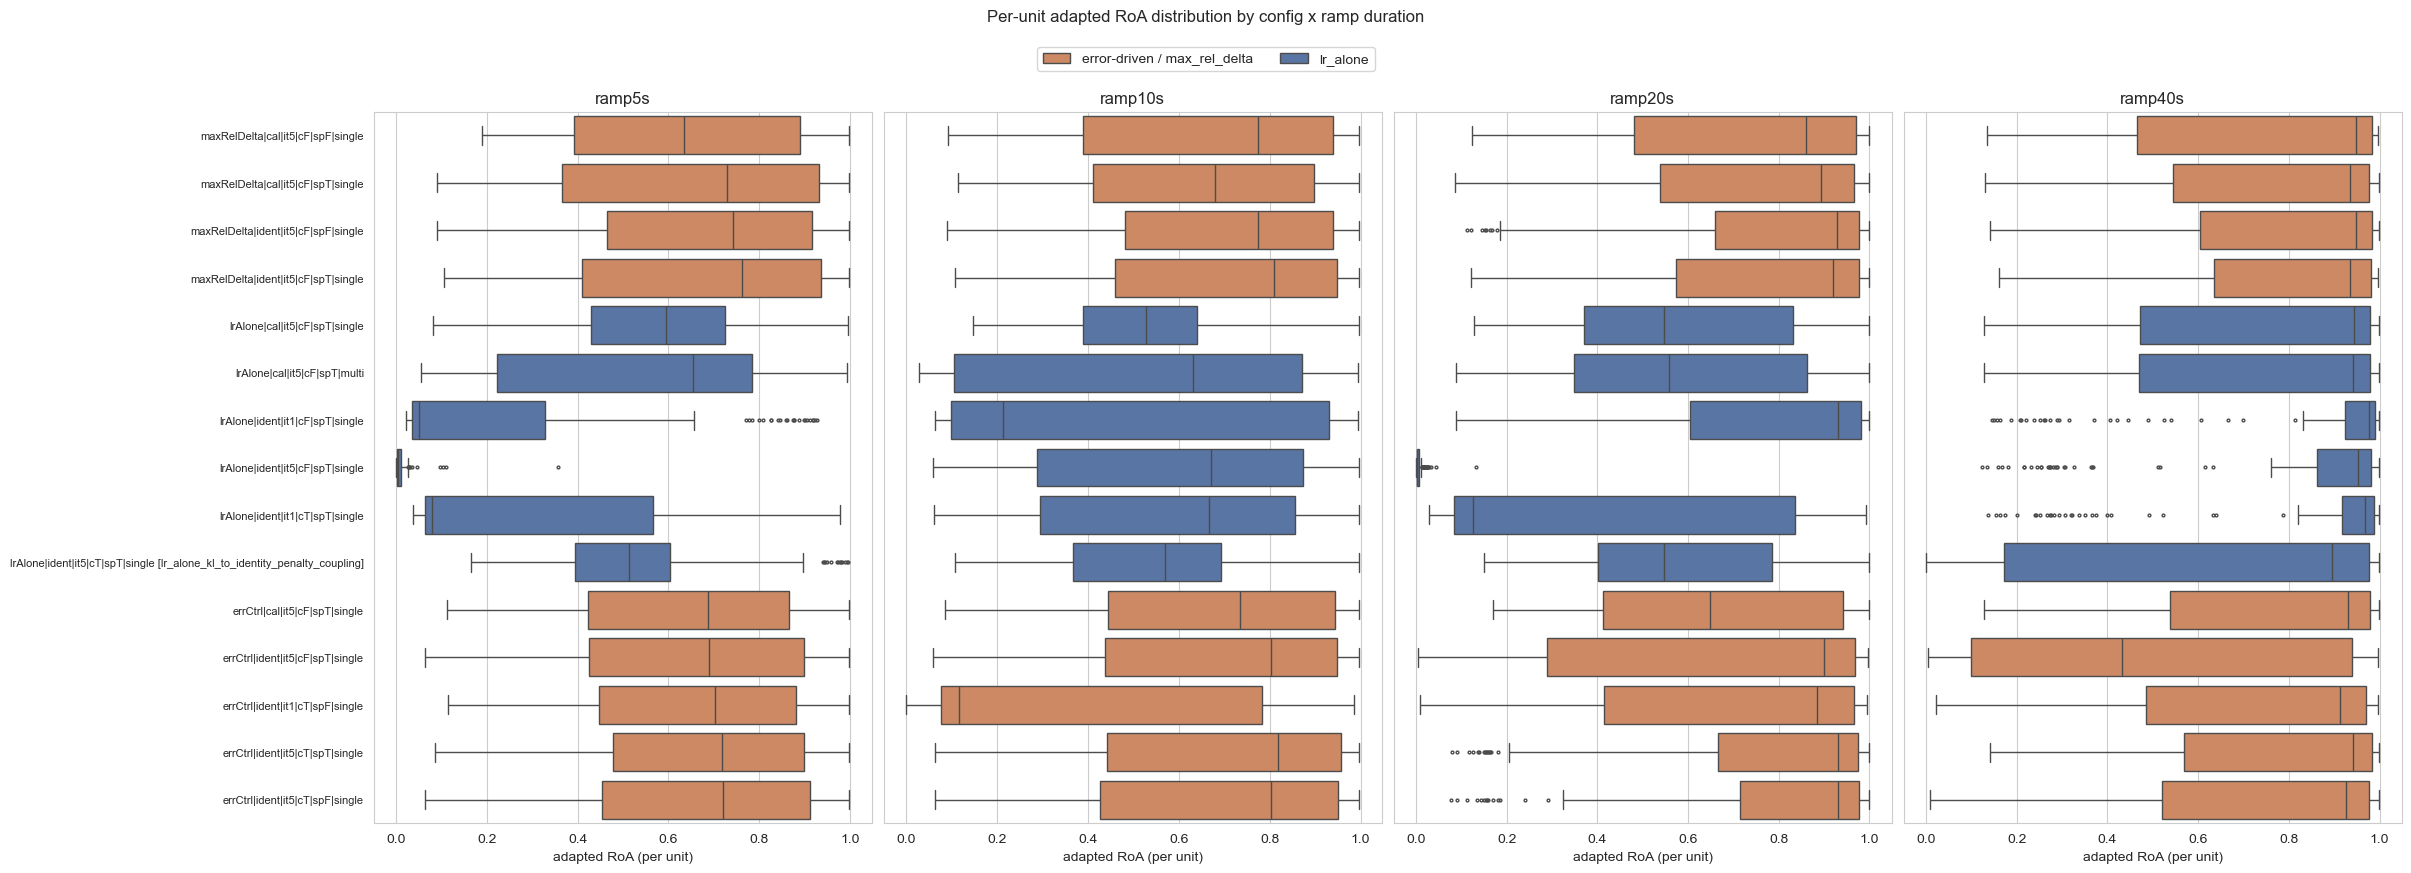

In [6]:
df_plot = df[df['label'].isin(label_order)].copy()
df_plot['label'] = pd.Categorical(df_plot['label'], categories=label_order, ordered=True)

fig, axes = plt.subplots(1, 4, figsize=(24, 0.32 * len(label_order) + 3), constrained_layout=True)
palette = {True: '#4C72B0', False: '#DD8452'}
for j, (ax, cond) in enumerate(zip(axes, COND_ORDER)):
    sub = df_plot[df_plot.condition == cond]
    sns.boxplot(data=sub, y='label', x='roa_adapted', hue='lr_alone', ax=ax,
                palette=palette, dodge=False, fliersize=2, orient='h')
    ax.set_title(cond.replace('triangular-', ''))
    ax.set_xlabel('adapted RoA (per unit)')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)
    if j > 0:
        ax.set_yticklabels([])
        ax.tick_params(left=False)
    leg = ax.get_legend()
    if leg:
        leg.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['lr_alone' if l == 'True' else 'error-driven / max_rel_delta' for l in labels],
           loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('Per-unit adapted RoA distribution by config x ramp duration', fontsize=12, y=1.1)
plt.show()

## 6. Pooled comparison -- best performing config overall

Every SNR and every ramp duration pooled into a single distribution per config, to answer "which
config wins overall" rather than "which config wins on which condition". Sorted by median pooled RoA.

C:\Users\Irene\AppData\Local\Temp\ipykernel_2204\2912357059.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pooled_order = (df_plot.groupby('label')['roa_adapted'].median()
C:\Users\Irene\AppData\Local\Temp\ipykernel_2204\2912357059.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, y='label', x='roa_adapted', order=pooled_order, ax=ax,


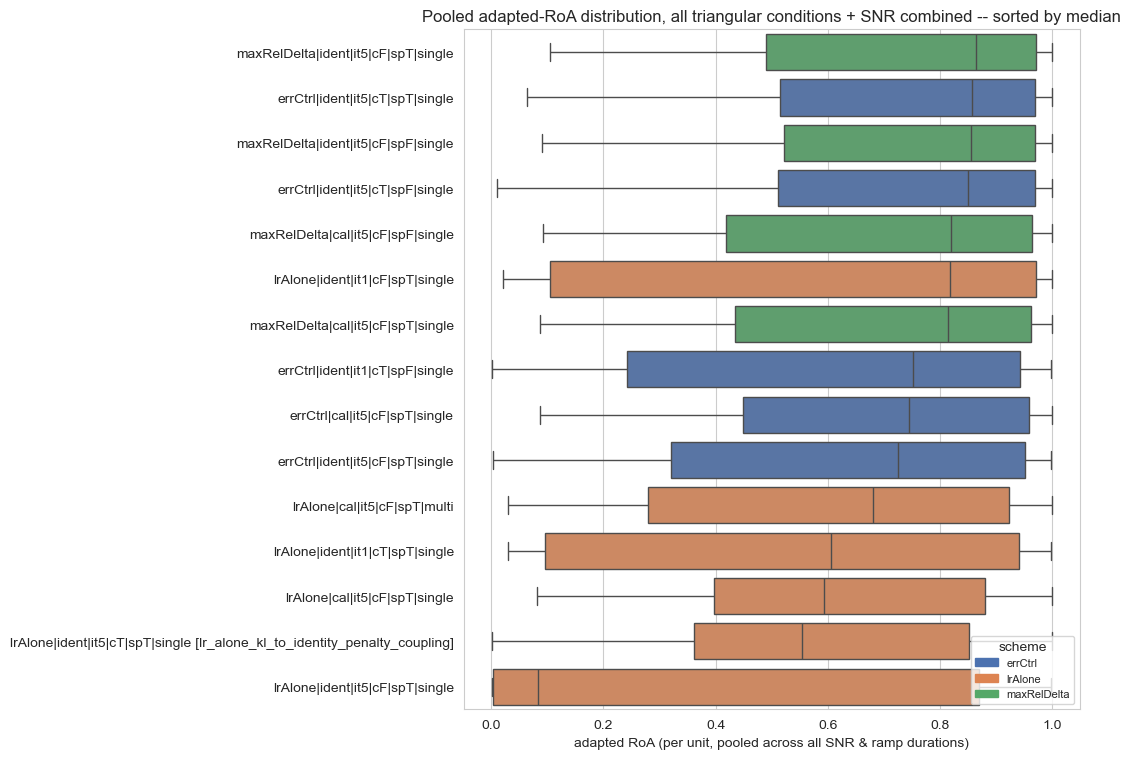

Best overall config (pooled across SNR & ramp duration): maxRelDelta|ident|it5|cF|spT|single


C:\Users\Irene\AppData\Local\Temp\ipykernel_2204\2912357059.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pooled_summary = (df_plot.groupby('label')


,mean_roa,median_roa,pct_roa90,n
label,,,,
maxRelDelta|ident|it5|cF|spT|single,73.0,86.4,45.9,606
errCtrl|ident|it5|cT|spT|single,73.0,85.7,44.4,606
maxRelDelta|ident|it5|cF|spF|single,73.5,85.5,44.1,606
errCtrl|ident|it5|cT|spF|single,72.0,85.0,43.4,606
maxRelDelta|cal|it5|cF|spF|single,69.5,82.0,39.8,606
lrAlone|ident|it1|cF|spT|single,57.9,81.8,42.2,606
maxRelDelta|cal|it5|cF|spT|single,69.4,81.4,39.3,606
errCtrl|ident|it1|cT|spF|single,61.2,75.1,35.3,606
errCtrl|cal|it5|cF|spT|single,68.3,74.5,35.5,606


In [7]:
scheme_of = cfg_df.drop_duplicates('label').set_index('label')['update_scheme']
lr_alone_of = cfg_df.drop_duplicates('label').set_index('label')['lr_alone']


def category_of(label):
    if scheme_of.get(label) == 'max_rel_delta':
        return 'maxRelDelta'
    return 'lrAlone' if lr_alone_of.get(label) else 'errCtrl'


pooled_order = (df_plot.groupby('label')['roa_adapted'].median()
                        .sort_values(ascending=False).index.tolist())
cat_palette = {'errCtrl': '#4C72B0', 'lrAlone': '#DD8452', 'maxRelDelta': '#55A868'}
row_colors = [cat_palette[category_of(l)] for l in pooled_order]

fig, ax = plt.subplots(figsize=(11, 0.38 * len(pooled_order) + 2))
sns.boxplot(data=df_plot, y='label', x='roa_adapted', order=pooled_order, ax=ax,
            palette=row_colors, fliersize=2, orient='h')
ax.set_xlabel('adapted RoA (per unit, pooled across all SNR & ramp durations)')
ax.set_ylabel('')
ax.set_title('Pooled adapted-RoA distribution, all triangular conditions + SNR combined -- sorted by median')
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in cat_palette.items()]
ax.legend(handles=handles, loc='lower right', fontsize=8, title='scheme')
plt.tight_layout()
plt.show()

pooled_summary = (df_plot.groupby('label')
                          .agg(mean_roa=('roa_adapted', lambda s: s.mean() * 100),
                               median_roa=('roa_adapted', lambda s: s.median() * 100),
                               pct_roa90=('roa_adapted', lambda s: (s >= 0.9).mean() * 100),
                               n=('roa_adapted', 'size'))
                          .reindex(pooled_order).round(1))
print("Best overall config (pooled across SNR & ramp duration):", pooled_order[0])
pooled_summary

## 7. Does the tuned step size predict performance? A cross-condition surrogate model

Every config variant above was tuned **independently per condition**, against a single
`(subject, SNR)` reference recording, with no notion of the other conditions or variants. That means
each `(lr_v, lr_b)` or `(max_rel_delta_v, max_rel_delta_b)` pair sitting in `cfg_df` is really one
noisy sample from an unknown, expensive-to-evaluate response surface -- exactly the setting
**Bayesian Optimization's internal surrogate model** is built for: fit a probabilistic regression
model (typically a Gaussian Process) over *all* observed `(hyperparameters -> outcome)` pairs across
every task, and use it to borrow statistical strength across conditions instead of trusting any single
condition's isolated search.

That's what this section does: pool every `(variant, condition)` pair into one dataset and fit
- a **Gaussian Process** (Matern kernel, the standard choice for small-N response-surface modelling --
  the same tool that packages like `scikit-optimize`/`GPyOpt` use internally for BO), scored via
  leave-one-out cross-validation since N is small (~60 rows) and a held-out split would be too noisy, and
- a small **Random Forest** purely for an interpretable feature-importance ranking.

This is exploratory/diagnostic given the sample size -- treat the leave-one-out R² as "is there
learnable signal at all", not as a validated production model.

In [8]:
model_df = summary.merge(cfg_df, on=['variant', 'condition', 'label'], how='left')
model_df['ramp_s'] = model_df['condition'].str.extract(r'(\d+)s').astype(float)
model_df['log_step_v'] = np.log10(model_df['step_v'])
model_df['log_step_b'] = np.log10(model_df['step_b'])
model_df['lr_alone_num'] = model_df['lr_alone'].astype(int)
model_df['coupling_num'] = model_df['coupling'].astype(int)

num_features = ['log_step_v', 'log_step_b', 'ramp_s', 'sv_epochs', 'lr_alone_num', 'coupling_num']
cat_features = ['wh_mode', 'update_scheme']
X = model_df[num_features + cat_features]
y = model_df['mean_roa_adapted'].values

pre = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])

kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)
gp_pipe = Pipeline([('pre', pre),
                     ('gp', GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                                      n_restarts_optimizer=5, random_state=0))])

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(gp_pipe, X, y, cv=loo)
r2_loo = 1 - np.sum((y - y_pred_loo) ** 2) / np.sum((y - y.mean()) ** 2)
mae_loo = np.mean(np.abs(y - y_pred_loo))
print(f"GP surrogate, leave-one-out: R2={r2_loo:.2f}   MAE={mae_loo:.1f} RoA points   (n={len(y)})")

gp_pipe.fit(X, y)

rf_pipe = Pipeline([('pre', pre), ('rf', RandomForestRegressor(n_estimators=500, max_depth=4, random_state=0))])
y_pred_rf = cross_val_predict(rf_pipe, X, y, cv=loo)
r2_rf = 1 - np.sum((y - y_pred_rf) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"RF surrogate,  leave-one-out: R2={r2_rf:.2f}")

rf_pipe.fit(X, y)
feat_names = num_features + list(rf_pipe.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_features))
imp_df = pd.DataFrame({'feature': feat_names, 'importance': rf_pipe.named_steps['rf'].feature_importances_})
imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

GP surrogate, leave-one-out: R2=0.79   MAE=4.9 RoA points   (n=60)


RF surrogate,  leave-one-out: R2=0.58


,feature,importance
0,log_step_b,0.443835
1,log_step_v,0.240023
2,ramp_s,0.170370
3,lr_alone_num,0.082529
4,max_iter_b,0.041090
5,coupling_num,0.017917
6,wh_mode_kl_to_identity,0.001924
7,wh_mode_kl_to_cal,0.001315
8,update_scheme_natural_gradient,0.000539
9,update_scheme_max_rel_delta,0.000458


`log_step_b` dominating the importance ranking is exactly what the manual investigation across the
`fdsi_09`/`coupling`/`sv5` notebooks kept finding by hand: the separation-vector step size is the
single biggest lever on whether a config collapses, far more than which condition it's applied to.
The partial-dependence view below makes that concrete: for the `natural_gradient` scheme there's a
visible "safe zone" below roughly `log10(step_b) ~ -2.5` (~0.003) and a cliff above it; the
`max_rel_delta` scheme (right panel) stays comparatively flat across the whole range it's actually
been tuned into, consistent with it never producing a catastrophic collapse in the data above.

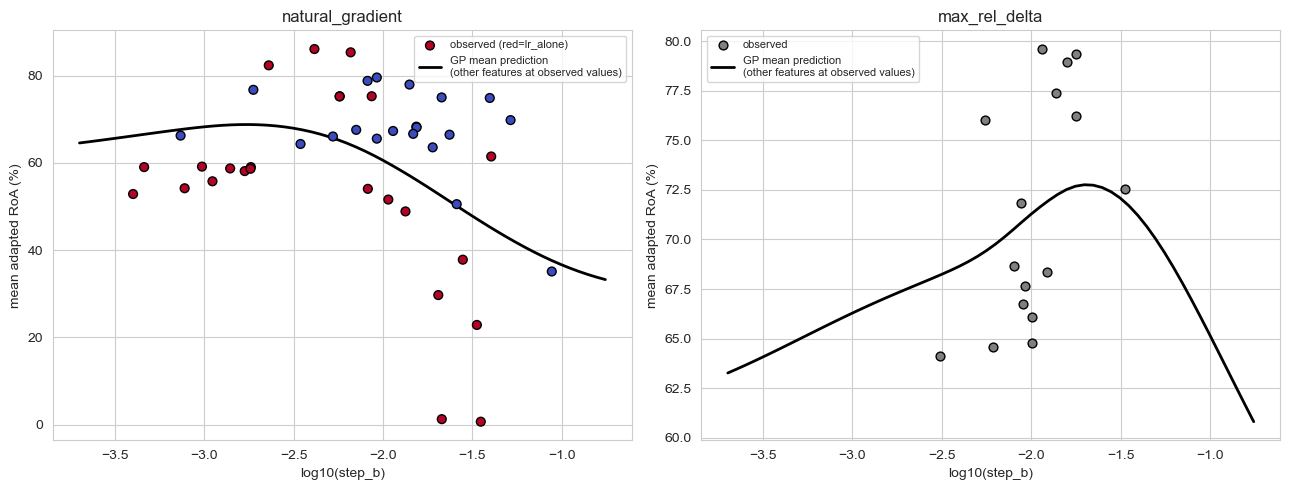

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grid = np.linspace(model_df['log_step_b'].min() - 0.3, model_df['log_step_b'].max() + 0.3, 60)

for scheme, ax in zip(['natural_gradient', 'max_rel_delta'], axes):
    sub = model_df[model_df.update_scheme == scheme]
    if scheme == 'natural_gradient':
        ax.scatter(sub['log_step_b'], sub['mean_roa_adapted'], c=sub['lr_alone_num'],
                   cmap='coolwarm', s=40, edgecolor='k', zorder=3, label='observed (red=lr_alone)')
    else:
        ax.scatter(sub['log_step_b'], sub['mean_roa_adapted'], color='gray',
                   s=40, edgecolor='k', zorder=3, label='observed')
    preds = []
    for g in grid:
        Xq = sub.copy()
        Xq['log_step_b'] = g
        preds.append(gp_pipe.predict(Xq[num_features + cat_features]).mean())
    ax.plot(grid, preds, color='black', lw=2, label='GP mean prediction\n(other features at observed values)')
    ax.set_title(scheme)
    ax.set_xlabel('log10(step_b)')
    ax.set_ylabel('mean adapted RoA (%)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Would a cross-condition model have suggested a better `step_b` for the failed configs?

For every config whose mean adapted RoA collapsed below 20%, query the fitted GP over a grid of
`step_b` values -- holding every other feature (condition, scheme, coupling, `max_iter_b`, ...) fixed
at that config's actual values -- and report the value the surrogate would have proposed instead, and
its predicted RoA there. This is the direct test of "would regressing over the working configs have
caught this": the isolated per-condition CMA-ES search never saw any other condition's outcome, so it
had no way to know its chosen `step_b` was far outside the region that works everywhere else.

**This is a model-based suggestion only** -- nothing here re-runs `AdaptDecomp`, so treat it as a
hypothesis to test by actually rerunning that condition with the suggested `step_b`, not as a
validated fix.

In [10]:
FAIL_THRESH = 20.0
failed = model_df[model_df.mean_roa_adapted < FAIL_THRESH].copy()
print(f"configs with mean adapted RoA < {FAIL_THRESH}%: {len(failed)}")

suggestions = []
for _, row in failed.iterrows():
    scheme = row['update_scheme']
    sub = model_df[model_df.update_scheme == scheme]
    b_grid = np.linspace(sub['log_step_b'].min() - 0.5, sub['log_step_b'].max() + 0.5, 200)
    Xq = pd.concat([row.to_frame().T] * len(b_grid), ignore_index=True)
    Xq['log_step_b'] = b_grid
    for c in num_features:
        Xq[c] = pd.to_numeric(Xq[c])
    preds = gp_pipe.predict(Xq[num_features + cat_features])
    best_i = np.argmax(preds)
    suggestions.append(dict(
        label=row['label'], condition=row['condition'],
        actual_step_b=row['step_b'], actual_roa=row['mean_roa_adapted'],
        suggested_step_b=10 ** b_grid[best_i], predicted_roa_at_suggestion=preds[best_i],
    ))

sugg_df = pd.DataFrame(suggestions)
sugg_df

configs with mean adapted RoA < 20.0%: 2


,label,condition,actual_step_b,actual_roa,suggested_step_b,predicted_roa_at_suggestion
0,lrAlone|ident|it5|cF|spT|single,triangular-ramp20s,0.035326,0.674162,0.000389,63.871800
1,lrAlone|ident|it5|cF|spT|single,triangular-ramp5s,0.021370,1.254208,0.000160,57.981565


## Caveats

- **N is small** (~60 rows total, fewer per `update_scheme`) -- the GP's leave-one-out score is a
  reasonable sanity check that there's learnable signal, not proof the suggested `step_b` values are
  correct. Treat section 8's table as a prioritized list of experiments to try, not a result.
- The target here is **RoA**, not the surrogate `wh_loss + sv_loss` that CMA-ES itself optimizes for
  each condition -- this cross-condition model sidesteps the proxy-objective mismatch discussed
  earlier (a config can have low surrogate loss and still collapse in RoA), which is exactly why it's
  able to flag configs that CMA-ES's own per-condition objective could not.
- `sil` is included for reference only; it is a calibration-time property and is expected to be flat
  across configs for the same `(subject, condition, snr)` -- it is **not** a measure of adaptation
  quality.
- Re-run this notebook once the currently in-flight `fdsi_0X` notebooks finish -- newly cached configs
  will be picked up automatically and excluded configs (printed in section 3) will shrink.